      SMART STOCK ANALYSIS SYSTEM (CONSOLE)      
Starting live market simulation for 10 iterations...
Press Ctrl+C at any time in your terminal to stop early.

Iteration   Current Price   Predicted Price   Trading Action 
-----------------------------------------------------------------
#1          $163.50         $165.13           BUY SIGNAL
#2          $161.12         $165.10           BUY SIGNAL
#3          $162.32         $165.34           BUY SIGNAL
#4          $162.06         $165.45           BUY SIGNAL
#5          $162.98         $165.71           BUY SIGNAL
#6          $161.51         $165.61           BUY SIGNAL
#7          $161.56         $165.51           BUY SIGNAL
#8          $159.57         $165.06           BUY SIGNAL
#9          $161.95         $165.08           BUY SIGNAL
#10         $163.68         $165.36           BUY SIGNAL

[System Update] Displaying visual plots... (Close the chart window to see the next one)


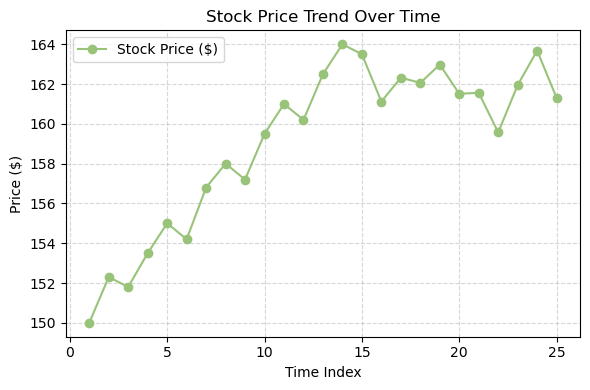

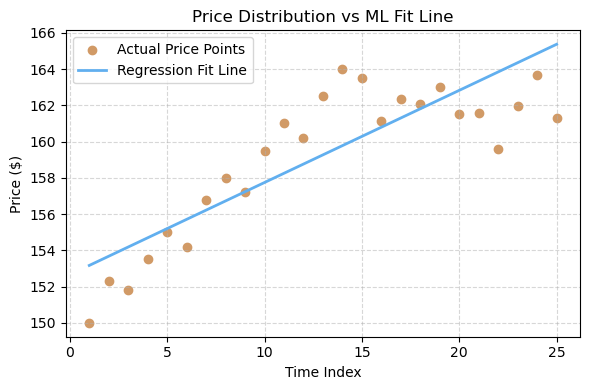

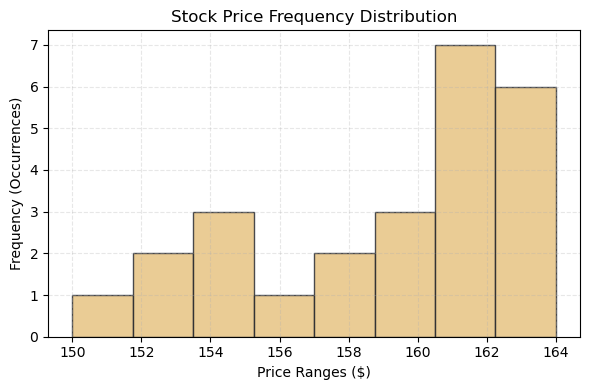

In [3]:
# ====================================================================
# LIBRARIES AND DEPENDENCIES EXPLANATION
# ====================================================================
# numpy: Used for high-performance numerical operations and array reshaping.
#        LinearRegression requires features (X) to be in a 2D array format.
import numpy as np

# pandas: Used for structured data handling and manipulation (DataFrames/Series).
import pandas as pd

# matplotlib.pyplot: Used to generate the 3 graphical plots (Line, Scatter, Histogram).
import matplotlib.pyplot as plt

# LinearRegression: The Machine Learning model from scikit-learn that computes y = mx + c.
from sklearn.linear_model import LinearRegression

# random: Used to simulate real-time stock price fluctuations every 5 seconds.
import random

# time: Used to handle the 5-second execution delay loop (time.sleep).
import time

class SmartStockAnalysisConsole:
    def __init__(self):
        # Print introductory console headers
        print("=" * 50)
        print("      SMART STOCK ANALYSIS SYSTEM (CONSOLE)      ")
        print("=" * 50)

        # --- SIMULATED DATA SETUP ---
        # time_steps represents our Independent Variable (X) / Time Index.
        # It is reshaped into a 2D column vector (-1, 1) as required by scikit-learn.
        self.time_steps = np.array(list(range(1, 16))).reshape(-1, 1) 
        
        # prices represents our Dependent Variable (Y) / Historical Price values.
        self.prices = [150.0, 152.3, 151.8, 153.5, 155.0, 154.2, 156.8, 158.0, 157.2, 159.5, 161.0, 160.2, 162.5, 164.0, 163.5]
        
        # Set the current starting price to the last entry in our historical data list
        self.current_price = self.prices[-1]
        
        # Variable to hold our machine learning model's future price prediction
        self.predicted_price = 0.0
        
        # Initialize an instance of the Linear Regression object (stored in-memory)
        self.model = LinearRegression()

    def train_and_predict(self):
        """Trains the Linear Regression model and predicts the next price point."""
        # Step 1: Train/Fit the mathematical model using historical X (time) and Y (price) data
        self.model.fit(self.time_steps, self.prices)
        
        # Step 2: Determine the next sequential time index step to run a prediction for
        next_time_index = len(self.time_steps) + 1
        next_time_step_array = np.array([[next_time_index]])
        
        # Step 3: Run inference to calculate the predicted future price point
        self.predicted_price = float(self.model.predict(next_time_step_array)[0])

    def generate_signal(self):
        """Generates a trading action signal by comparing predicted price to current price."""
        # Define a baseline percentage change threshold (0.5% shift required to trigger an action)
        threshold = 0.005 
        
        # Calculate expected fractional return rate: (Predicted - Current) / Current
        expected_return = (self.predicted_price - self.current_price) / self.current_price

        # Check conditions against the threshold limit
        if expected_return > threshold:
            # Price expected to rise: Return BUY signal highlighted in Green text (\033[92m)
            return "\033[92mBUY SIGNAL\033[0m"
        elif expected_return < -threshold:
            # Price expected to fall: Return SELL signal highlighted in Red text (\033[91m)
            return "\033[91mSELL SIGNAL\033[0m"
        else:
            # Price stable within limits: Return HOLD signal highlighted in Yellow text (\033[93m)
            return "\033[93mHOLD SIGNAL\033[0m"

    def update_market_price(self):
        """Simulates real stock market shifts by adding random price fluctuations."""
        # Generate a random float variance between -2.5 and +2.5 dollars
        price_change = random.uniform(-2.5, 2.5)
        
        # Update current price while ensuring it never drops below a floor value of $10.00
        self.current_price = max(10.0, self.current_price + price_change)
        
        # Append the new rounded price calculation into the history tracking list
        self.prices.append(round(self.current_price, 2))
        
        # Append a new corresponding sequential tracking entry into the time matrix array
        new_time_step = len(self.prices)
        self.time_steps = np.append(self.time_steps, [[new_time_step]], axis=0)

    def show_plots(self):
        """Displays line graph, scatter plot, and histogram using Matplotlib."""
        print("\n[System Update] Displaying visual plots... (Close the chart window to see the next one)")
        
        # -------------------------------------------------------------
        # PLOT 1: STANDARD LINE TREND GRAPH
        # -------------------------------------------------------------
        plt.figure("Historical Stock Trend", figsize=(6, 4))
        # Flatten time_steps back to 1D to properly map across the horizontal X-axis line tracking
        plt.plot(self.time_steps.flatten(), self.prices, marker='o', color='#98c379', label="Stock Price ($)")
        plt.title("Stock Price Trend Over Time")
        plt.xlabel("Time Index")
        plt.ylabel("Price ($)")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show() # Halts code execution sequentially until chart UI window is closed

        # -------------------------------------------------------------
        # PLOT 2: LINEAR REGRESSION SCATTER PLOT
        # -------------------------------------------------------------
        plt.figure("Linear Regression Model", figsize=(6, 4))
        # Plot raw historical coordinates as independent dots/points
        plt.scatter(self.time_steps.flatten(), self.prices, color='#d19a66', label="Actual Price Points")
        
        # Pass full time matrix vector to plot the model's computed global best-fit line
        predicted_trend = self.model.predict(self.time_steps)
        plt.plot(self.time_steps.flatten(), predicted_trend, color='#61afef', linewidth=2, label="Regression Fit Line")
        
        plt.title("Price Distribution vs ML Fit Line")
        plt.xlabel("Time Index")
        plt.ylabel("Price ($)")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------------------
        # PLOT 3: FREQUENCY DISTRIBUTION HISTOGRAM
        # -------------------------------------------------------------
        plt.figure("Price Histogram Analysis", figsize=(6, 4))
        # Bins classify how pricing occurrences segregate across specific dollar bandwidth ranges
        plt.hist(self.prices, bins=8, color='#e5c07b', edgecolor='#1e222b', alpha=0.8)
        plt.title("Stock Price Frequency Distribution")
        plt.xlabel("Price Ranges ($)")
        plt.ylabel("Frequency (Occurrences)")
        plt.grid(True, linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()

    def start_simulation(self, cycles=10):
        """Executes the core simulation tracking loop based on user defined iterations."""
        print(f"Starting live market simulation for {cycles} iterations...")
        print("Press Ctrl+C at any time in your terminal to stop early.\n")
        
        # Format aligned column spacing headers directly in the console terminal
        print(f"{'Iteration':<12}{'Current Price':<16}{'Predicted Price':<18}{'Trading Action':<15}")
        print("-" * 65)

        try:
            # Loop execution runs for designated iteration limits
            for i in range(1, cycles + 1):
                # 1. Re-train linear formula using updated dataset and compute next prediction
                self.train_and_predict()
                
                # 2. Extract action suggestion flag string based on current data state
                signal = self.generate_signal()
                
                # 3. Print clean row matching output to terminal
                print(f"#{i:<11}${self.current_price:<15.2f}${self.predicted_price:<17.2f}{signal:<15}")
                
                # 4. Wait exactly 5 seconds to simulate real-time market frequency
                time.sleep(5)
                
                # 5. Mutate price metrics to update state variables for the next step iteration
                self.update_market_price()

            # Automatically render graphical charts once looping sequences are complete
            self.show_plots()

        except KeyboardInterrupt:
            # Safeguard catch intercept allowing clean escape via Ctrl+C without losing plot visuals
            print("\nSimulation paused by user interaction.")
            self.show_plots()

# Entry point validation wrapper
if __name__ == "__main__":
    # Create object instance
    system = SmartStockAnalysisConsole()
    
    # Run loop logic execution chain (Set to 10 cycles)
    system.start_simulation(cycles=10)